### Forecasting Noise Patterns

Now the moment of truth we take our model. We are going to use the 3 year historical data loaded between 2021-2024
to predict the varability in noise complaints of various PUMAs in NYC. 

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import random
from datetime import date, timedelta
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import geopandas as gpd
from keplergl import KeplerGl
from helpers import ( 
                    prep_the_data, 
                      export_puma_kepler, 
                      make_daily_table_for_model_with_nta,
                        make_typical_week_2025,
                      make_daily_observed_2025,
                      load_idata,
                      compare_models_loo_waic,
                      kepler_typical_week_from_dow_complaint,
                      score_against_real_2025_days,
                      crps_from_draws, 
                      elpd_from_draws,
                      random_summer_date,
                      summarize_forecast_metrics,
                      forest_day_puma_intervals,
                      plot_puma_day_interval,
                      plot_coverage_curve,
                      normalize_summary_for_comparison,
                      rebuild_daily_cmp_2025_model4
                    )




### Load + prepare data: 2021-2024 

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()


In [6]:
df_puma_2021__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2022-06-09,day,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Thursday,June,0,June__2022,Animal,ANIMAL__Thursday
2,4103,Noise,"Noise, Barking Dog",NaN,2022-06-16,day,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Thursday,June,0,June__2022,Animal,ANIMAL__Thursday
3,4103,Noise,"Noise, Barking Dog",NaN,2022-08-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Tuesday,August,0,August__2022,Animal,ANIMAL__Tuesday
4,4103,Noise,"Noise, Barking Dog",NaN,2022-08-09,day,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Tuesday,August,0,August__2022,Animal,ANIMAL__Tuesday


### We are going to focus on modeling Social / Party, given that we observed that it's has the highest noise complaints

In [7]:
COMPLAINT = "Social / Party"
# COMPLAINT = "Animal"
# COMPLAINT = "Construction / Industrial"
# COMPLAINT = "Mechanical Equipment"

# Rebuild daily_df_train exactly as in training
daily_df_train, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_value=COMPLAINT,
)



In [8]:
# Rebuild puma → nta mapping
puma_nta_map = (
    daily_df_train[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)


In [9]:

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()


We're going to load the previous model.

In [10]:
idata_nta = load_idata("../data/processed/models/model3_nta_idata.nc")

✅ Loaded idata <- ../data/processed/models/model3_nta_idata.nc


WE begin by building the posterior 

In [11]:
lam_post = idata_nta.posterior["lam"]

# Posterior mean forecast
df_forecast = (
    lam_post
    .mean(dim=("chain", "draw"))
    .to_dataframe(name="lam_forecast")
    .reset_index()
)


In [12]:
hdi = az.hdi(lam_post, hdi_prob=0.9)["lam"]

hdi_df = (
    hdi.to_dataframe(name="lam_hdi")
       .reset_index()
       .pivot_table(
           index=["puma", "dow"],
           columns="hdi",
           values="lam_hdi",
       )
       .reset_index()
       .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
)

df_forecast = df_forecast.merge(hdi_df, on=["puma", "dow"], how="left")
df_forecast["lam_width_90"] = (
    df_forecast["lam_high_90"] - df_forecast["lam_low_90"]
)


In [13]:
df_puma_311_2025 = df_puma.loc[
    (df_puma["created_bucket"] >= "2025-01-01") &
     (df_puma["time_of_day"] ==  "night")
].copy()


In [14]:
df_puma_311_2025.head()


,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
50,4103,Noise,"Noise, Barking Dog",NaN,2025-06-17,night,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Tuesday,June,0,June__2025,Animal,ANIMAL__Tuesday
53,4103,Noise,"Noise, Barking Dog",NaN,2025-07-04,night,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Friday,July,0,July__2025,Animal,ANIMAL__Friday
55,4103,Noise,"Noise, Barking Dog",NaN,2025-07-16,night,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Wednesday,July,0,July__2025,Animal,ANIMAL__Wednesday
57,4103,Noise,"Noise, Barking Dog",NaN,2025-07-26,night,1,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Saturday,July,1,July__2025,Animal,ANIMAL__Saturday
60,4103,Noise,"Noise, Barking Dog",NaN,2025-08-17,night,2,MN0301,0.245574,Chinatown-Two Bridges,Chinatown-Two Bridges — 4103,Sunday,August,1,August__2025,Animal,ANIMAL__Sunday


In [15]:
typical_2025 = make_typical_week_2025(
    df_puma_311_2025,
    complaint_col="descriptor_group"
)


In [16]:
# -----------------------------
# Compare Model 3 (forecast) vs observed 2025 typical week
# -----------------------------
cmp_2025_model3 = (
    df_forecast
    .merge(typical_2025, on=["puma", "dow"], how="left")
)

# Point error vs forecast mean (lam_forecast)
cmp_2025_model3["error"] = cmp_2025_model3["observed_2025"] - cmp_2025_model3["lam_forecast"]
cmp_2025_model3["abs_error"] = cmp_2025_model3["error"].abs()

# Coverage of the *lam* interval (rate uncertainty)
cmp_2025_model3["within_90_lam"] = (
    (cmp_2025_model3["observed_2025"] >= cmp_2025_model3["lam_low_90"]) &
    (cmp_2025_model3["observed_2025"] <= cmp_2025_model3["lam_high_90"])
)

# Interval width (sharpness)
cmp_2025_model3["lam_width_90"] = cmp_2025_model3["lam_high_90"] - cmp_2025_model3["lam_low_90"]


In [17]:
# Summary stats (lam-interval-based)
summary_m3 = {
    "N": int(len(cmp_2025_model3)),
    "MAE (lam_forecast)": float(cmp_2025_model3["abs_error"].mean()),
    "Median AE (lam_forecast)": float(cmp_2025_model3["abs_error"].median()),
    "90% Coverage (lam interval)": float(cmp_2025_model3["within_90_lam"].mean()),
    "Median lam interval width (90%)": float(cmp_2025_model3["lam_width_90"].median()),
    "Mean lam interval width (90%)": float(cmp_2025_model3["lam_width_90"].mean()),
}
summary_m3

{'N': 385,
 'MAE (lam_forecast)': 12.478073373778175,
 'Median AE (lam_forecast)': 8.580669493185233,
 '90% Coverage (lam interval)': 0.04155844155844156,
 'Median lam interval width (90%)': 2.7491147587150557,
 'Mean lam interval width (90%)': 2.980802974510056}

In [18]:

# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,          # or None
    complaint_col="descriptor_group",
)



In [19]:
# -----------------------------
# 1) Merge forecast (keyed by puma,dow)
#    Use df_forecast_week if that's your current object.
# -----------------------------
forecast = df_forecast_week if "df_forecast_week" in globals() else df_forecast

daily_cmp_2025_model3 = daily_2025.merge(
    forecast,
    on=["puma", "dow"],
    how="left",
)

# -----------------------------
# 2) Comparison columns (point forecast errors)
# -----------------------------
daily_cmp_2025_model3["error"] = (
    daily_cmp_2025_model3["daily_count"] - daily_cmp_2025_model3["lam_forecast"]
)
daily_cmp_2025_model3["abs_error"] = daily_cmp_2025_model3["error"].abs()

# Mean-rate interval coverage (NOT predictive)
if {"lam_low_90", "lam_high_90"}.issubset(daily_cmp_2025_model3.columns):
    daily_cmp_2025_model3["within_90_lam"] = (
        (daily_cmp_2025_model3["daily_count"] >= daily_cmp_2025_model3["lam_low_90"]) &
        (daily_cmp_2025_model3["daily_count"] <= daily_cmp_2025_model3["lam_high_90"])
    )
else:
    daily_cmp_2025_model3["within_90_lam"] = pd.NA

# -----------------------------
# 3) Build puma_idx / dow_idx aligned to training coords
# -----------------------------
puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

daily_cmp_2025_model3["puma_idx"] = daily_cmp_2025_model3["puma"].astype(str).map(puma_to_idx)
daily_cmp_2025_model3["dow_idx"]  = daily_cmp_2025_model3["dow"].astype(str).map(dow_to_idx)

# Drop any rows not present in training coords
daily_cmp_2025_model3 = daily_cmp_2025_model3.dropna(subset=["puma_idx", "dow_idx"]).copy()
daily_cmp_2025_model3["puma_idx"] = daily_cmp_2025_model3["puma_idx"].astype(int)
daily_cmp_2025_model3["dow_idx"]  = daily_cmp_2025_model3["dow_idx"].astype(int)

# -----------------------------
# 4) Posterior predictive draws for Model 3 (Poisson)
# -----------------------------
lam_draws_m3 = (
    idata_nta.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (n_puma, n_dow, S)

p_idx = daily_cmp_2025_model3["puma_idx"].to_numpy()
d_idx = daily_cmp_2025_model3["dow_idx"].to_numpy()

mu_draws_m3 = lam_draws_m3[p_idx, d_idx, :]  # (n_days, S)

rng = np.random.default_rng(42)
y_pp_model3 = rng.poisson(mu_draws_m3)       # (n_days, S)


In [20]:

# Stack posterior draws
lam_draws_m3 = (
    idata_nta.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (n_puma, n_dow, S)

# Select lam draws per 2025 day
p_idx = daily_cmp_2025_model3["puma_idx"].to_numpy()
d_idx = daily_cmp_2025_model3["dow_idx"].to_numpy()

mu_draws_m3 = lam_draws_m3[p_idx, d_idx, :]  # (n_days, S)

# Poisson posterior predictive
rng = np.random.default_rng(42)
y_pp_model3 = rng.poisson(mu_draws_m3)

In [21]:
gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    daily_cmp_2025_model3,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path="../data/processed/kepler/model3_daily_forecast_vs_2025.geojson",
)


✅ Kepler GeoJSON written to: ../data/processed/kepler/model3_daily_forecast_vs_2025.geojson


In [22]:
daily_df, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_col="descriptor_group",
)

In [23]:
# daily_df has: puma, nta_name, puma_idx, nta_idx, dow_idx, daily_count

# Build a unique mapping: puma_idx -> nta_idx
puma_nta_map = (
    daily_df[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)

# sanity check: each puma maps to exactly 1 nta
assert puma_nta_map["puma_idx"].is_unique, "A PUMA maps to multiple NTAs (check your join)."

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()  # shape (n_puma,)


In [24]:
# -----------------------------
# Data for the model
# -----------------------------
y = daily_df["daily_count"].to_numpy(dtype=int)
puma_idx_obs = daily_df["puma_idx"].to_numpy(dtype=int)
dow_idx_obs  = daily_df["dow_idx"].to_numpy(dtype=int)
year_idx_obs= daily_df["year_idx"].to_numpy(dtype=int)

In [25]:
with pm.Model(coords=coords) as m_nb_year:

    # -----------------------------
    # NTA-level weekday baseline (log scale)
    # -----------------------------
    mu_nta = pm.Normal("mu_nta", mu=0.0, sigma=1.5, dims=("nta", "dow"))

    # -----------------------------
    # PUMA-level deviation (partial pooling) by dow
    # -----------------------------
    sigma_puma = pm.Exponential("sigma_puma", 2.0)  # tighter for stability
    delta_puma = pm.Normal(
        "delta_puma",
        mu=0.0,
        sigma=sigma_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Base (puma, dow) log-rate grid
    # -----------------------------
    log_lambda = pm.Deterministic(
        "log_lambda",
        mu_nta[puma_to_nta_idx, :] + delta_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Year-level mean shift (partial pooling)
    # -----------------------------
    sigma_year = pm.Exponential("sigma_year", 1.0)
    year_offset = pm.Normal("year_offset", 0.0, sigma=sigma_year, dims=("year",))

    # -----------------------------
    # Observation-level log-mean / mean
    # -----------------------------
    log_mu_obs = log_lambda[puma_idx_obs, dow_idx_obs] + year_offset[year_idx_obs]
    mu_obs = pm.Deterministic("mu_obs", pm.math.exp(log_mu_obs), dims=("obs",))

    # -----------------------------
    # Dispersion by day-of-week
    # Var(Y) = mu + mu^2/alpha
    # -----------------------------
    alpha_dow = pm.Exponential("alpha_dow", 1.0, dims=("dow",))

    # -----------------------------
    # Likelihood
    # -----------------------------
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu_obs,
        alpha=alpha_dow[dow_idx_obs],
        observed=y,
    )

    idata_nta_nb = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.94,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_nta, sigma_puma, delta_puma, sigma_year, year_offset, alpha_dow]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1045 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [26]:
loo_table, waic_table = compare_models_loo_waic(idata_nta_nb, idata_nta, m2_name="Model 4 (NTA pooled + NB)", m3_name="Model 3 (NTA pooled, Poisson)")


/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 4 (NTA pooled + NB),0,-53628.167640,473.743703,0.000000,0.883321,179.173141,0.000000,True,log
"Model 3 (NTA pooled, Poisson)",1,-110296.669331,4244.475978,56668.501691,0.116679,7437.874043,7306.917596,True,log


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 4 (NTA pooled + NB),0,-53641.730860,487.306924,0.000000,0.883272,185.458224,0.000000,True,log
"Model 3 (NTA pooled, Poisson)",1,-112771.528779,6719.335426,59129.797919,0.116728,8757.860079,8619.692143,True,log


In [27]:
post = idata_nta_nb.posterior

# If lam is missing, reconstruct it from log_lambda
if "lam" in post:
    lam_post = post["lam"]  # (chain, draw, puma, dow)
else:
    # log_lambda is (chain, draw, puma, dow)
    lam_post = np.exp(post["log_lambda"])

# Posterior mean of lam
df_forecast_week = (
    lam_post.mean(dim=("chain", "draw"))
            .to_dataframe()
            .reset_index()
            .rename(columns={lam_post.name if hasattr(lam_post, "name") else 0: "lam_forecast"})
)

# 90% HDI for lam
hdi = az.hdi(lam_post, hdi_prob=0.9)  # returns DataArray with dim "hdi"

# Convert HDI to columns
lam_low = hdi.sel(hdi="lower").to_dataframe().reset_index()
lam_high = hdi.sel(hdi="higher").to_dataframe().reset_index()

# The value column name is not stable; rename it robustly
valcol_low = [c for c in lam_low.columns if c not in ("puma", "dow")][0]
valcol_high = [c for c in lam_high.columns if c not in ("puma", "dow")][0]
lam_low = lam_low.rename(columns={valcol_low: "lam_low_90"})
lam_high = lam_high.rename(columns={valcol_high: "lam_high_90"})

df_forecast_week = (
    df_forecast_week
    .merge(lam_low[["puma", "dow", "lam_low_90"]], on=["puma", "dow"], how="left")
    .merge(lam_high[["puma", "dow", "lam_high_90"]], on=["puma", "dow"], how="left")
)
df_forecast_week["lam_width_90"] = df_forecast_week["lam_high_90"] - df_forecast_week["lam_low_90"]


In [28]:


scored_2025, y_pp_model4_2025, summary_2025 = score_against_real_2025_days(
    daily_2025=daily_2025,          # must have puma,dow,date,daily_count
    idata=idata_nta_nb,             # your fitted year-aware NB model idata
    coords=coords,                  # training coords (includes "year")
    year_fallback="nearest",          # use "nearest" if 2025 not in coords["year"]
)

summary_2025


{'MAE': 16.985124203189052,
 'Median AE': 12.169201160020117,
 '90% Coverage (predictive)': 0.7884933774834437,
 'N_days': 4832,
 'used_year_offset': True,
 'used_day_shock': False}

In [29]:
# Usage
y_obs = scored_2025["daily_count"].to_numpy()
crps = crps_from_draws(y_pp_model4_2025, y_obs, pair_subsample=256)

crps_summary = {
    "mean_CRPS": float(np.mean(crps)),
    "median_CRPS": float(np.median(crps)),
}
crps_summary

{'mean_CRPS': 10.45891653139228, 'median_CRPS': 7.124600708007812}

In [30]:
# Usage
y_obs = scored_2025["daily_count"].to_numpy().astype(int)
elpd_total, elpd_mean, lpd = elpd_from_draws(y_pp_model4_2025, y_obs, smoothing=1.0)

elpd_summary = {
    "ELPD_total": elpd_total,
    "ELPD_mean": elpd_mean,  # per-row average log score
}
elpd_summary


{'ELPD_total': -19496.415108616784, 'ELPD_mean': -4.034854120160758}

In [31]:

summary_2025 = summarize_forecast_metrics(scored_2025, y_pp_model4_2025, level=0.90)
summary_2025


{'N': 4832,
 'MAE(mu_pred_mean)': 16.985124203189052,
 'Coverage@90': 0.7884933774834437,
 'Median PI width@90': 46.0,
 'Mean CRPS': 10.45891653139228,
 'Median CRPS': 7.124600708007812,
 'ELPD_total (draws)': -19496.415108616784,
 'ELPD_mean (draws)': -4.034854120160758}

In [32]:
# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,          # or None
    complaint_col="descriptor_group",
)


In [33]:
target_date = random_summer_date(2025)

df_one_day = (
    scored_2025
    .copy()
    .assign(date=lambda d: pd.to_datetime(d["date"]).dt.normalize())
    .loc[lambda d: d["date"] == pd.Timestamp(target_date)]
)

print("rows kept:", len(df_one_day))
df_one_day.head()

rows kept: 55


,puma,date,dow,daily_count,year,puma_idx,dow_idx,year_idx,date_idx,mu_pred_mean,y_pred_low_90,y_pred_high_90,within_90_pred,error,abs_error
41,4103,2025-07-12,Saturday,39,2025,0,5,2,None,69.404506,23.0,136.0,True,-30.404506,30.404506
131,4104,2025-07-12,Saturday,11,2025,1,5,2,None,33.119575,10.0,67.0,True,-22.119575,22.119575
221,4107,2025-07-12,Saturday,12,2025,2,5,2,None,91.299828,29.0,175.0,False,-79.299828,79.299828
302,4108,2025-07-12,Saturday,3,2025,3,5,2,None,19.789827,6.0,40.0,False,-16.789827,16.789827
388,4109,2025-07-12,Saturday,21,2025,4,5,2,None,73.454014,24.0,141.0,False,-52.454014,52.454014


In [34]:
daily_cmp_2025_model4, y_pp_model4 = rebuild_daily_cmp_2025_model4(
    daily_2025=daily_2025,
    idata=idata_nta_nb,
    coords=coords,
    df_forecast_week=df_forecast_week,  # optional, only if you want lam_forecast columns too
)

print("rows:", len(daily_cmp_2025_model4))
print("coverage@90:", daily_cmp_2025_model4["within_90_pred"].mean())
print("MAE(mu):", daily_cmp_2025_model4["abs_error_mu"].mean())


rows: 4832
coverage@90: 0.12562086092715233
MAE(mu): 17.628049542532935


In [35]:
# -----------------------------
# 5) Export to Kepler
# -----------------------------
cols_keep = [
    "puma", "date", "dow",
    "daily_count",
    # "lam_forecast",
    "mu_pred_mean",
    "y_pred_low_90", 
    "y_pred_high_90",
    "error", "abs_error",
    "within_90_pred",
]
cols_keep = [c for c in cols_keep if c in daily_cmp_2025_model4.columns]
out_path="../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson"



# gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
#     daily_cmp_2025_model4[cols_keep],
#     puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
#     out_path=out_path

# )

gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    df_one_day[cols_keep],
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path=out_path

)


print(f"✅ Kepler export written: {out_path}")
print("✅ y_pp_model4 shape:", y_pp_model4.shape)


✅ Kepler GeoJSON written to: ../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson
✅ Kepler export written: ../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson
✅ y_pp_model4 shape: (4832, 4000)


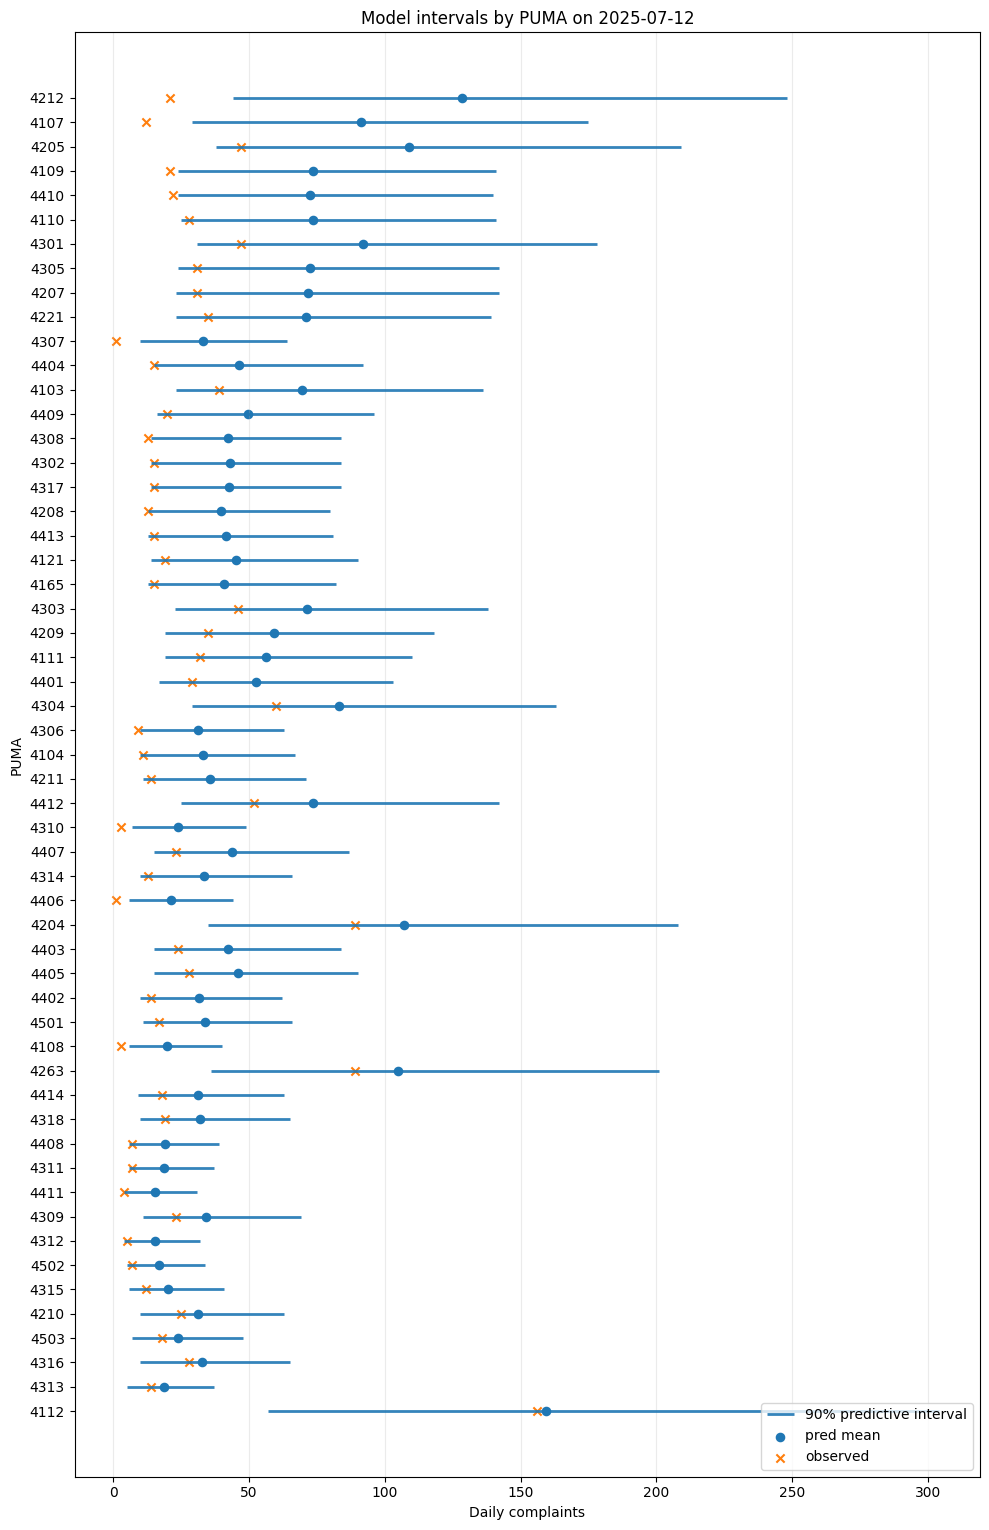

In [36]:

# Example:
day_tbl = forest_day_puma_intervals(
    scored_2025,
    date=target_date,
    sort_by="abs_error",
    top_n=55,   # or 30 for readability
)


     puma       date       dow  daily_count  mu_pred_mean  y_pred_low_90  \
930  4204 2025-07-12  Saturday           89    107.200356           35.0   

     y_pred_high_90  
930          208.05  


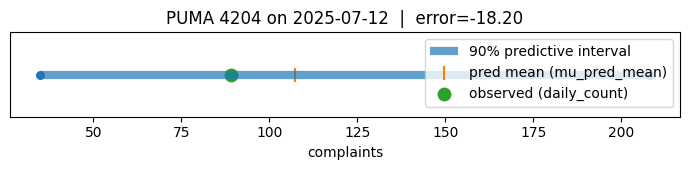

In [37]:


# Example:
plot_puma_day_interval(scored_2025, puma="4204", date=target_date)


In [38]:


def summarize_model_performance(df: pd.DataFrame) -> dict:
    """
    Summarize model performance.

    Supports:
    - Poisson / typical-week outputs:
        observed_2025, lam_forecast, lam_low_90, lam_high_90
    - NB daily predictive outputs:
        daily_count, mu_pred_mean, y_pred_low_90, y_pred_high_90

    Returns metrics for:
    - Point accuracy (MAE, Median AE)
    - Interval coverage
    - Interval width
    """

    # -----------------------------
    # Observed values
    # -----------------------------
    if "daily_count" in df.columns:
        y_obs = df["daily_count"].to_numpy()
    elif "observed_2025" in df.columns:
        y_obs = df["observed_2025"].to_numpy()
    else:
        raise KeyError("Need 'daily_count' or 'observed_2025'.")

    # -----------------------------
    # Point prediction
    # -----------------------------
    if "mu_pred_mean" in df.columns:
        y_hat = df["mu_pred_mean"].to_numpy()
        pred_label = "mu_pred_mean"
    elif "lam_forecast" in df.columns:
        y_hat = df["lam_forecast"].to_numpy()
        pred_label = "lam_forecast"
    else:
        raise KeyError("Need 'mu_pred_mean' or 'lam_forecast'.")

    abs_err = np.abs(y_obs - y_hat)

    # -----------------------------
    # Interval selection
    # -----------------------------
    interval_type = None

    if {"y_pred_low_90", "y_pred_high_90"}.issubset(df.columns):
        lo = df["y_pred_low_90"].to_numpy()
        hi = df["y_pred_high_90"].to_numpy()
        interval_type = "predictive"
    elif {"lam_low_90", "lam_high_90"}.issubset(df.columns):
        lo = df["lam_low_90"].to_numpy()
        hi = df["lam_high_90"].to_numpy()
        interval_type = "lam"
    else:
        lo = hi = None

    # -----------------------------
    # Coverage + width
    # -----------------------------
    if lo is not None:
        coverage = np.mean((y_obs >= lo) & (y_obs <= hi))
        width = hi - lo
        width_mean = float(np.mean(width))
        width_median = float(np.median(width))
    else:
        coverage = np.nan
        width_mean = np.nan
        width_median = np.nan

    # -----------------------------
    # Assemble results
    # -----------------------------
    out = {
        "N": int(len(df)),
        f"MAE ({pred_label})": float(np.mean(abs_err)),
        f"Median AE ({pred_label})": float(np.median(abs_err)),
    }

    if interval_type is not None:
        out[f"90% Coverage ({interval_type} interval)"] = float(coverage)
        out[f"Median {interval_type} interval width (90%)"] = width_median
        out[f"Mean {interval_type} interval width (90%)"] = width_mean

    return out


In [39]:
row_m3 = normalize_summary_for_comparison(
    summarize_model_performance(cmp_2025_model3),
    model_label="Model 3 (Poisson, weekday mean)"
)

row_m4 = normalize_summary_for_comparison(
    summarize_model_performance(scored_2025),
    model_label="Model 4 (NB, daily predictive)"
)

comparison_df = pd.DataFrame([row_m3, row_m4])
comparison_df


,Model,N,Point MAE,Point Median AE,Coverage@90,Median Interval Width@90,Mean Interval Width@90,Interval Type
0,"Model 3 (Poisson, weekday mean)",385,12.478073,8.580669,0.041558,2.749115,2.980803,rate
1,"Model 4 (NB, daily predictive)",4832,16.985124,12.169201,0.788493,46.000000,58.616629,predictive


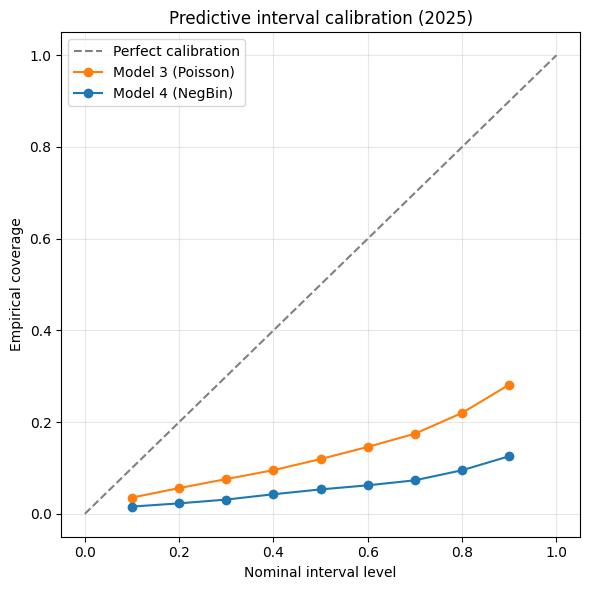

In [40]:


plt.figure(figsize=(6, 6))

# Diagonal = perfect calibration
x = np.linspace(0, 1, 100)
plt.plot(x, x, "--", color="gray", label="Perfect calibration")

# IMPORTANT: y_obs must align with y_pp rows
y_obs_m3 = daily_cmp_2025_model3["daily_count"].to_numpy()
y_obs_m4 = daily_cmp_2025_model4["daily_count"].to_numpy()

# Sanity checks
assert y_pp_model3.shape[0] == len(y_obs_m3), (y_pp_model3.shape, len(y_obs_m3))
assert y_pp_model4.shape[0] == len(y_obs_m4), (y_pp_model4.shape, len(y_obs_m4))

plot_coverage_curve(
    y_obs=y_obs_m3,
    y_pp=y_pp_model3,     # Poisson predictive draws
    label="Model 3 (Poisson)",
    color="C1",
)

plot_coverage_curve(
    y_obs=y_obs_m4,
    y_pp=y_pp_model4,     # NegBin predictive draws
    label="Model 4 (NegBin)",
    color="C0",
)

plt.xlabel("Nominal interval level")
plt.ylabel("Empirical coverage")
plt.title("Predictive interval calibration (2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
